In [31]:
%load_ext autoreload
%autoreload 2


import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

from src import metrics

df = yf.download("SPY, TSLA, NVDA, TLT, KO", start="2011-01-01", end="2026-10-01", auto_adjust=True)


[*******************   40%                       ]  2 of 5 completed

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[*********************100%***********************]  5 of 5 completed


In [32]:
close = df["Close"]
ret = metrics.daily_returns(prices=close)
vol = metrics.rolling_vol(returns=ret, window=20)

inv_vol = 1 / vol

weights = metrics.inverse_vol_weights(ret, 20)
ret_a = ret.loc[weights.index]
n = weights.shape[1]

eq_weights = pd.DataFrame(1 / n, index=weights.index, columns=weights.columns)

port_iv = (weights * ret_a).sum(axis=1)
port_ew = (eq_weights * ret_a).sum(axis=1)

bt = pd.DataFrame({"inv_vol": port_iv, "equal": port_ew}).dropna()
bt.head()

,inv_vol,equal
Date,,
2011-02-02,0.000447,0.008382
2011-02-03,-0.004538,-0.008479
2011-02-04,-0.001474,0.001608
2011-02-07,-0.000063,-0.009503
2011-02-08,0.003999,0.006567


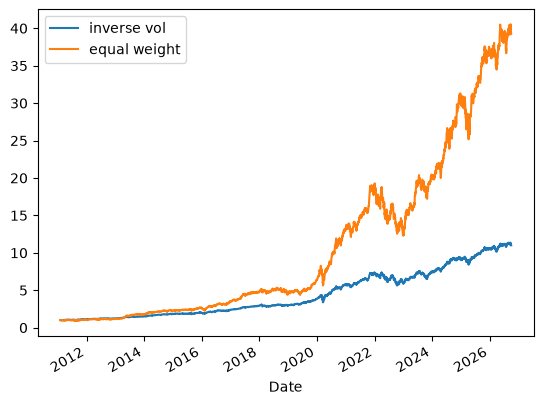

In [33]:
iv_eq = (1 + port_iv).cumprod()
ew_eq = (1 + port_ew).cumprod()

iv_eq.plot(label="inverse vol")
ew_eq.plot(label="equal weight")
plt.legend()
plt.show()

In [34]:
ew_stats = metrics.stats(port_ew)
iv_stats = metrics.stats(port_iv)

cost = 0.0005

port_iv, port_iv_net, turnover_iv = metrics.backtest_weights(weights=weights, r=ret, cost=cost)

#for a month scale
w_m = weights.resample("ME").last().reindex(weights.index).ffill()
port_m, port_m_net, turn_m = metrics.backtest_weights(w_m, ret, cost)

print(f"Avg daily turnover: {turnover_iv.mean():.4f}")
print(f"Annual turnover: {turnover_iv.mean() * 252:.1f}x")

print(f"Monthly annual turnover: {turn_m.mean() * 252:.1f}x")

table = pd.DataFrame(
    {
        "equal weight": metrics.stats(port_ew),
        "inverse vol": metrics.stats(port_iv),
        "inv vol (net)": metrics.stats(port_iv_net),
        "inv vol monthly": metrics.stats(port_m),
        "inv vol monthly (net)": metrics.stats(port_m_net),
    }
).T
table = table.round(3)
print(table.to_markdown())

Avg daily turnover: 0.0361
Annual turnover: 9.1x
Monthly annual turnover: 1.9x
|                       |   Total ret |   Ann. ret |   Ann. Vol |   Sharpe |   MaxDD |
|:----------------------|------------:|-----------:|-----------:|---------:|--------:|
| equal weight          |      38.267 |      0.265 |      0.202 |    1.263 |  -0.361 |
| inverse vol           |      10.006 |      0.166 |      0.128 |    1.266 |  -0.234 |
| inv vol (net)         |       9.251 |      0.161 |      0.128 |    1.23  |  -0.236 |
| inv vol monthly       |      10.023 |      0.166 |      0.129 |    1.259 |  -0.271 |
| inv vol monthly (net) |       9.861 |      0.165 |      0.129 |    1.252 |  -0.272 |


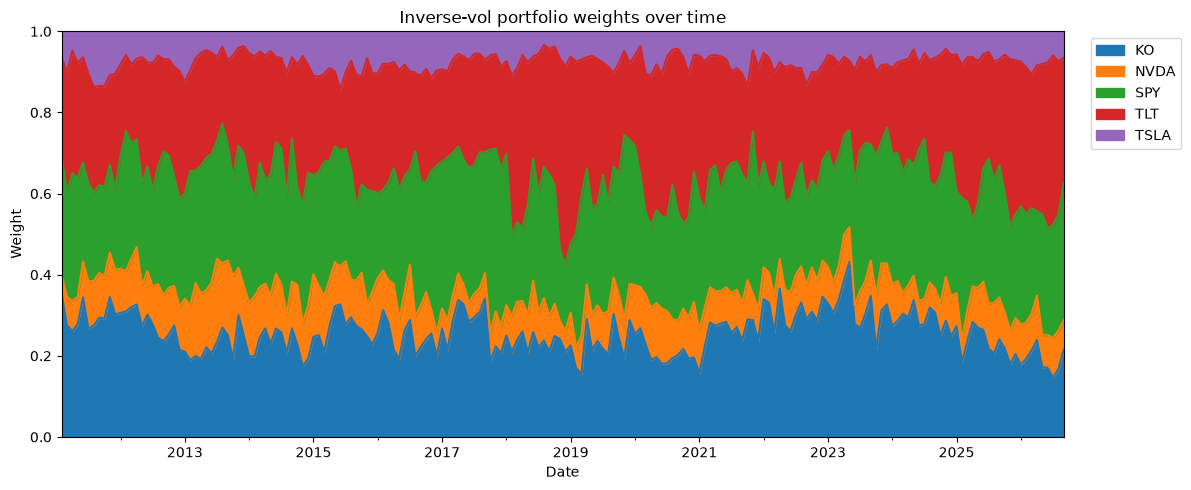

In [35]:
weights.resample("ME").mean().plot.area(figsize=(12, 5))
plt.title("Inverse-vol portfolio weights over time")
plt.ylabel("Weight")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../images/p4_weights", dpi=150)
plt.show()